# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Name:** _Perera W.A.L.S._ 

**Index Number:** _230487D_

**GitHub:** https://github.com/Lasan-Perera/EN3160-assignment-1


## Question 1: Piecewise Linear Intensity Transformation

Implement `intensity_transform(im, breakpoints)` and apply it to the given image with the breakpoints from the assignment. Experiment with different breakpoints for a visually pleasing result.

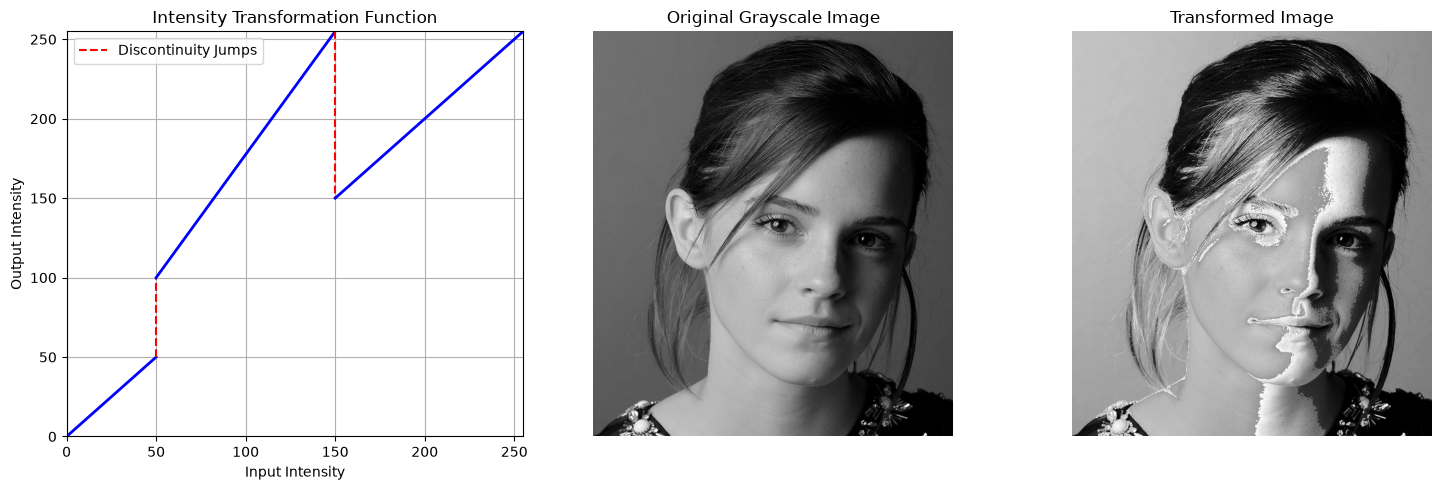

In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform_step(im):
    lut = np.zeros(256, dtype=np.uint8)
    
    # 0 <= x < 50 : y = x
    lut[0:50] = np.arange(0, 50)
    
    # 50 <= x < 150 : y maps from 100 to 255
    lut[50:150] = np.linspace(100, 255, 100, endpoint=False).astype(np.uint8)
    
    # 150 <= x <= 255 : y = x
    lut[150:256] = np.arange(150, 256)
    
    transformed_im = cv2.LUT(im, lut)
    return transformed_im, lut

# read the image in grayscale
img_gray = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/emma.jpg', cv2.IMREAD_GRAYSCALE)

# apply the transformation
transformed_img_gray, lut = intensity_transform_step(img_gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# plot piecewise step transformation
axes[0].plot([0, 50], [0, 50], 'b-', linewidth=2)
axes[0].plot([50, 50], [50, 100], 'r--', linewidth=1.5, label='Discontinuity Jumps')
axes[0].plot([50, 150], [100, 255], 'b-', linewidth=2)
axes[0].plot([150, 150], [255, 150], 'r--', linewidth=1.5)
axes[0].plot([150, 255], [150, 255], 'b-', linewidth=2)

axes[0].set_title('Intensity Transformation Function')
axes[0].set_xlabel('Input Intensity')
axes[0].set_ylabel('Output Intensity')
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)
axes[0].legend()

# original Image
axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original Grayscale Image')
axes[1].axis('off')

# transformed Image
axes[2].imshow(transformed_img_gray, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Question 2: Accentuating White and Gray Matter

Apply piecewise linear intensity transformations to the brain proton density image to accentuate (a) white matter and (b) gray matter separately.

### Brain Tissue Intensity Thresholds

For this implementation, we use the following 8-bit intensity thresholds:

- **0–70:** CSF
- **70–140:** Gray Matter (GM)
- **140–255:** White Matter (WM)

These thresholds are used as practical segmentation limits. MRI intensity values can vary between scanners and acquisition protocols, so these values are specific to our image-processing implementation rather than universal MRI thresholds.

**Source:** [Robitaille et al., 2012 — Tissue-Based MRI Intensity Standardization](https://pmc.ncbi.nlm.nih.gov/articles/PMC3352580/)

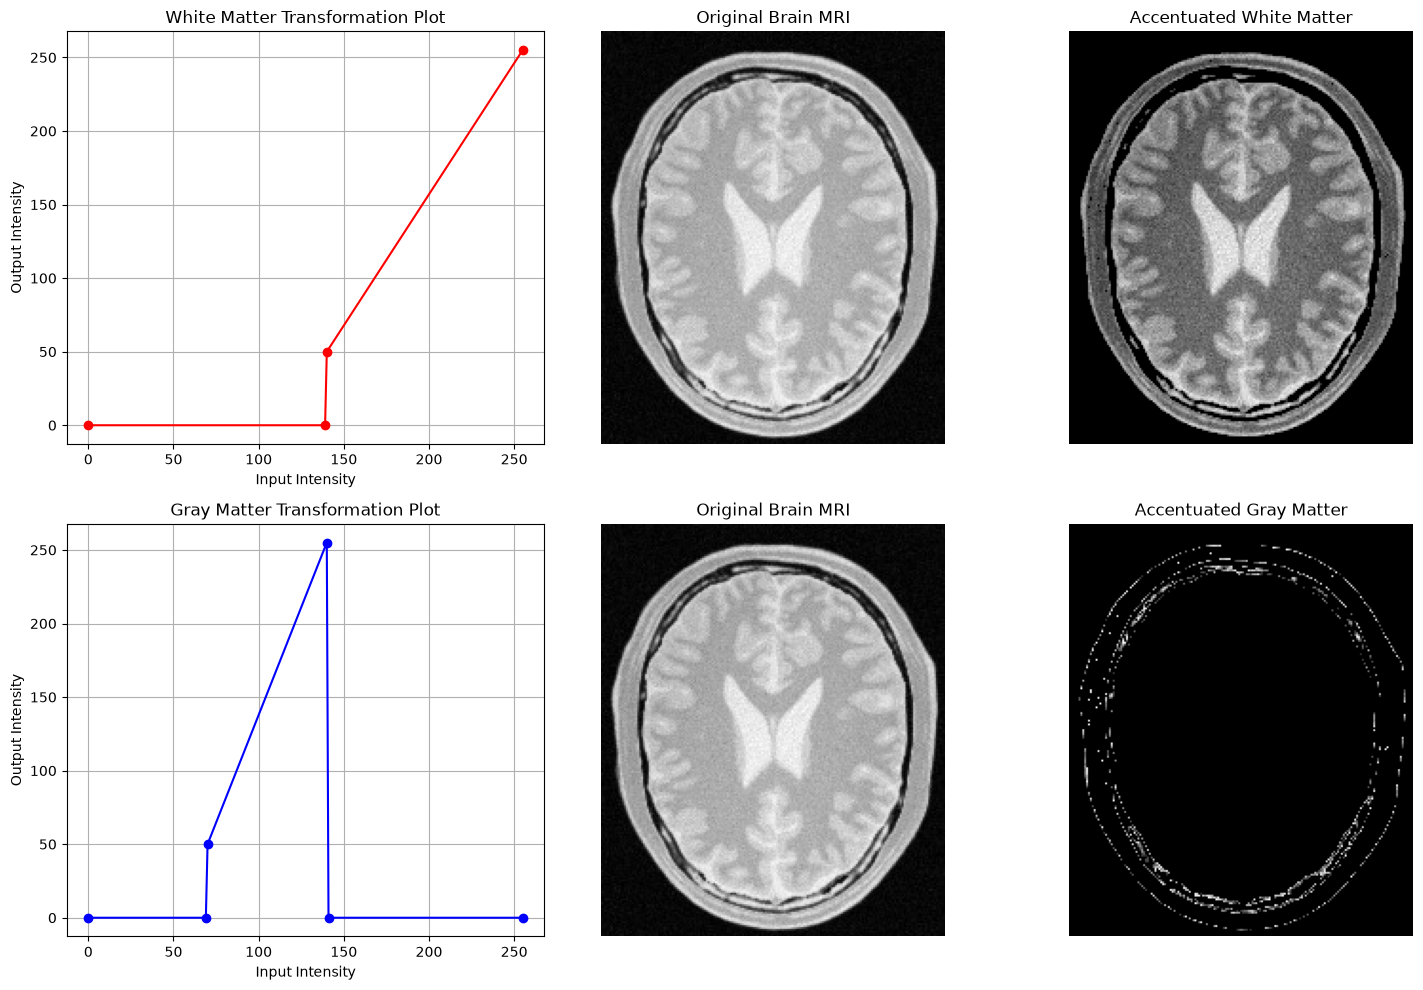

In [ ]:
def apply_custom_lut(img, breakpoints):
    breakpoints = np.array(breakpoints)
    x_pts = breakpoints[:, 0]
    y_pts = breakpoints[:, 1]
    
    input_range = np.arange(256)
    lut = np.interp(input_range, x_pts, y_pts).astype(np.uint8)
    
    transformed = cv2.LUT(img, lut)
    return transformed, lut

# Read the brain MRI image in grayscale
brain_img = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/brainProton.jpeg', cv2.IMREAD_GRAYSCALE)

# Define breakpoints for White Matter (WM: 140–255)
breakpoints_wm = [
    [0, 0],
    [139, 0],
    [140, 50],
    [255, 255]
]

# Define breakpoints for Gray Matter (GM: 70–140)
breakpoints_gm = [
    [0, 0],
    [69, 0],
    [70, 50],
    [140, 255],
    [141, 0],
    [255, 0]
]

# Apply transformations
img_wm, lut_wm = apply_custom_lut(brain_img, breakpoints_wm)
img_gm, lut_gm = apply_custom_lut(brain_img, breakpoints_gm)

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# White Matter Transformation Plot
axes[0, 0].plot([p[0] for p in breakpoints_wm], [p[1] for p in breakpoints_wm], 'r-o')
axes[0, 0].set_title('White Matter Transformation Plot')
axes[0, 0].set_xlabel('Input Intensity')
axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].grid(True)

axes[0, 1].imshow(brain_img, cmap='gray')
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_wm, cmap='gray')
axes[0, 2].set_title('Accentuated White Matter')
axes[0, 2].axis('off')

# Gray Matter Transformation Plot
axes[1, 0].plot([p[0] for p in breakpoints_gm], [p[1] for p in breakpoints_gm], 'b-o')
axes[1, 0].set_title('Gray Matter Transformation Plot')
axes[1, 0].set_xlabel('Input Intensity')
axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].grid(True)

axes[1, 1].imshow(brain_img, cmap='gray')
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_gm, cmap='gray')
axes[1, 2].set_title('Accentuated Gray Matter')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Question 3: Gamma Correction on the L Plane (L*a*b*)

Convert to L*a*b*, apply gamma correction to the L plane, state the gamma value used, and compare histograms before and after correction.

Applied Gamma Value is 0.2


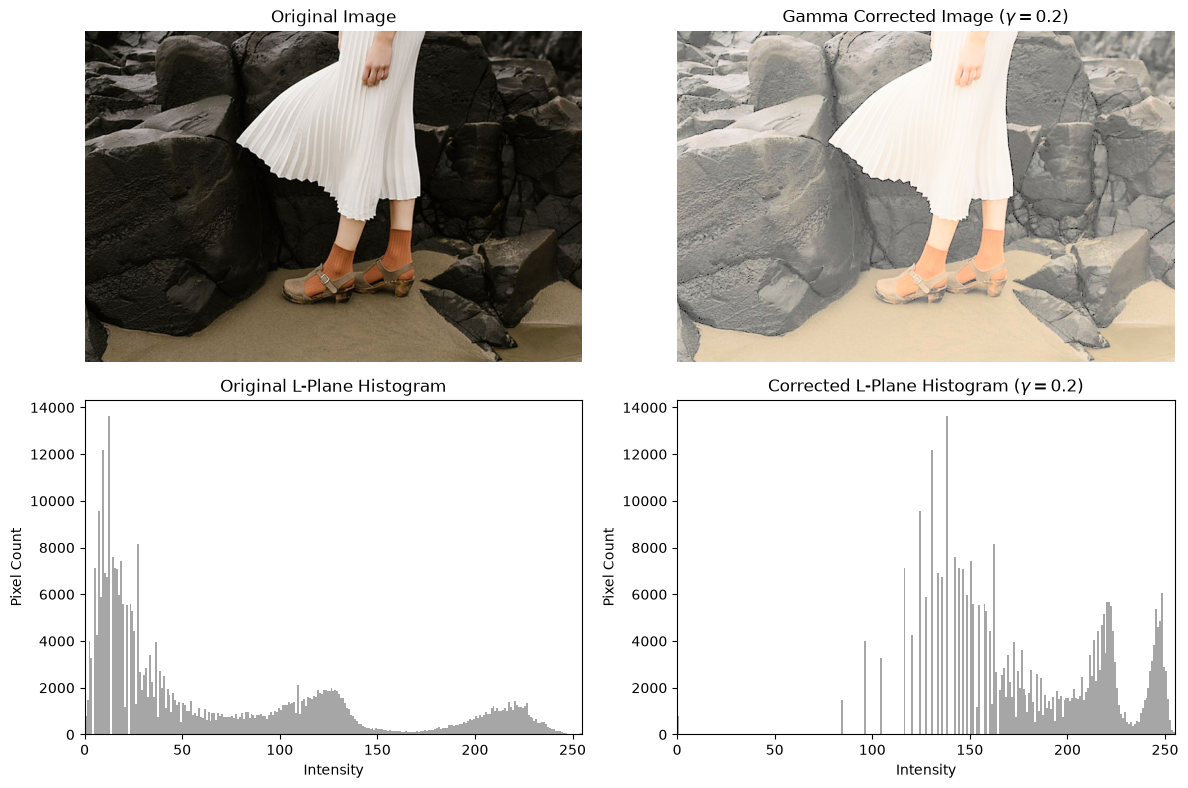

In [98]:
img_bgr = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/q3GammaCorr.jpeg') 
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to L*a*b* color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# Apply Gamma Correction to L plane
# gamma value < 1.0 brightens dark areas
# gamma value > 1.0 darkens bright areas
gamma = 0.2  
L_normalized = L / 255.0
L_corrected = np.uint8(np.clip((L_normalized ** gamma) * 255, 0, 255))

# Merge corrected L channel with original a and b channels, then convert back to RGB
img_lab_corrected = cv2.merge([L_corrected, a, b])
img_bgr_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
img_rgb_corrected = cv2.cvtColor(img_bgr_corrected, cv2.COLOR_BGR2RGB)

print(f"Applied Gamma Value is {gamma}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Gamma Corrected Image
axes[0, 1].imshow(img_rgb_corrected)
axes[0, 1].set_title(rf"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis("off")

# Original L-channel Histogram
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 0].set_title("Original L-Plane Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])

# Gamma Corrected L-channel Histogram
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axes[1, 1].set_title(rf"Corrected L-Plane Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()


## Question 4: Vibrance Enhancement via Saturation Plane

Split into HSV planes, apply the given Gaussian-weighted saturation boost f(x) with chosen a and sigma=70, recombine, and display results.

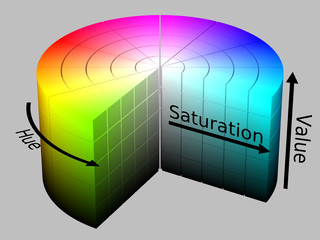

Reported chosen parameter value: a = 0.5


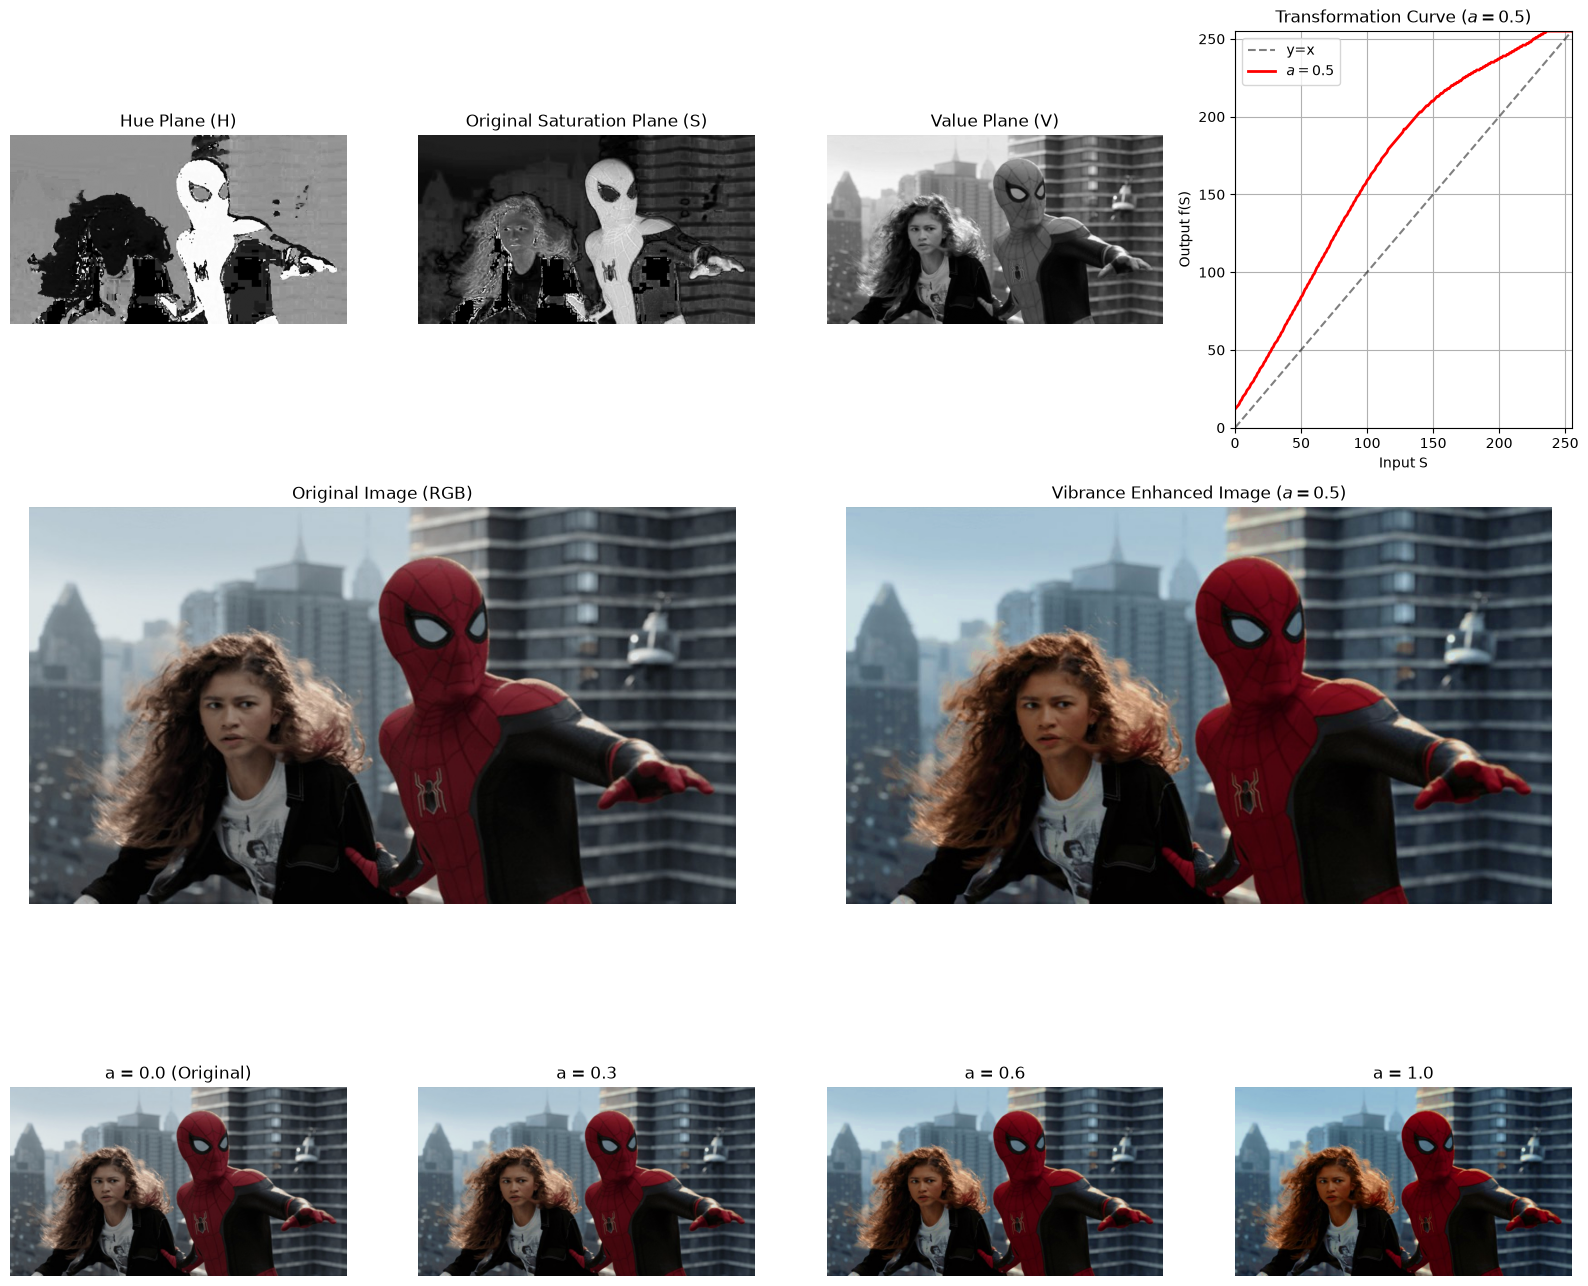

In [99]:
def vibrance_transform(s_channel, a, sigma=70):
    x = np.arange(256, dtype=np.float32)
    boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma ** 2)))
    fx = np.clip(x + boost, 0, 255).astype(np.uint8)
    s_enhanced = cv2.LUT(s_channel, fx)
    return s_enhanced, x, fx

img_bgr = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/SpiderMan.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to HSV color space and split channels
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

# parameter for vibrance enhancement
a_param = 0.5
print(f"Reported chosen parameter value: a = {a_param}")
s_enhanced, x_vals, fx_vals = vibrance_transform(s, a=a_param, sigma=70)

img_hsv_enhanced = cv2.merge([h, s_enhanced, v])
img_rgb_enhanced = cv2.cvtColor(img_hsv_enhanced, cv2.COLOR_HSV2RGB)

# Visualisation
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 4)

# HSV Planes and Transformation Curve
ax_h = fig.add_subplot(gs[0, 0])
ax_h.imshow(h, cmap='gray')
ax_h.set_title("Hue Plane (H)")
ax_h.axis("off")

ax_s = fig.add_subplot(gs[0, 1])
ax_s.imshow(s, cmap='gray')
ax_s.set_title("Original Saturation Plane (S)")
ax_s.axis("off")

ax_v = fig.add_subplot(gs[0, 2])
ax_v.imshow(v, cmap='gray')
ax_v.set_title("Value Plane (V)")
ax_v.axis("off")

# Curve plot spanning 1 column
ax_curve = fig.add_subplot(gs[0, 3])
ax_curve.plot(x_vals, x_vals, 'k--', alpha=0.5, label='y=x')
ax_curve.plot(x_vals, fx_vals, 'r-', linewidth=2, label=rf'$a={a_param}$')
ax_curve.set_title(rf"Transformation Curve ($a={a_param}$)")
ax_curve.set_xlabel("Input S")
ax_curve.set_ylabel("Output f(S)")
ax_curve.set_xlim([0, 255])
ax_curve.set_ylim([0, 255])
ax_curve.grid(True)
ax_curve.legend()

# before & after side-by-side
ax_orig = fig.add_subplot(gs[1, 0:2])
ax_orig.imshow(img_rgb)
ax_orig.set_title("Original Image (RGB)")
ax_orig.axis("off")

ax_enh = fig.add_subplot(gs[1, 2:4])
ax_enh.imshow(img_rgb_enhanced)
ax_enh.set_title(rf"Vibrance Enhanced Image ($a={a_param}$)")
ax_enh.axis("off")

# Effect of Varying Parameter 'a'
a_values = [0.0, 0.3, 0.6, 1.0]

for idx, a_val in enumerate(a_values):
    ax_a = fig.add_subplot(gs[2, idx])
    s_test, _, _ = vibrance_transform(s, a=a_val, sigma=70)
    hsv_test = cv2.merge([h, s_test, v])
    rgb_test = cv2.cvtColor(hsv_test, cv2.COLOR_HSV2RGB)
    
    ax_a.imshow(rgb_test)
    if a_val == 0.0:
        ax_a.set_title(f"a = {a_val} (Original)")
    else:
        ax_a.set_title(f"a = {a_val}")
    ax_a.axis("off")

plt.tight_layout()
plt.show()

## Question 5: Histogram Equalization (Custom Implementation)

Write your own histogram equalization function (no cv.equalizeHist) and show histograms before/after.

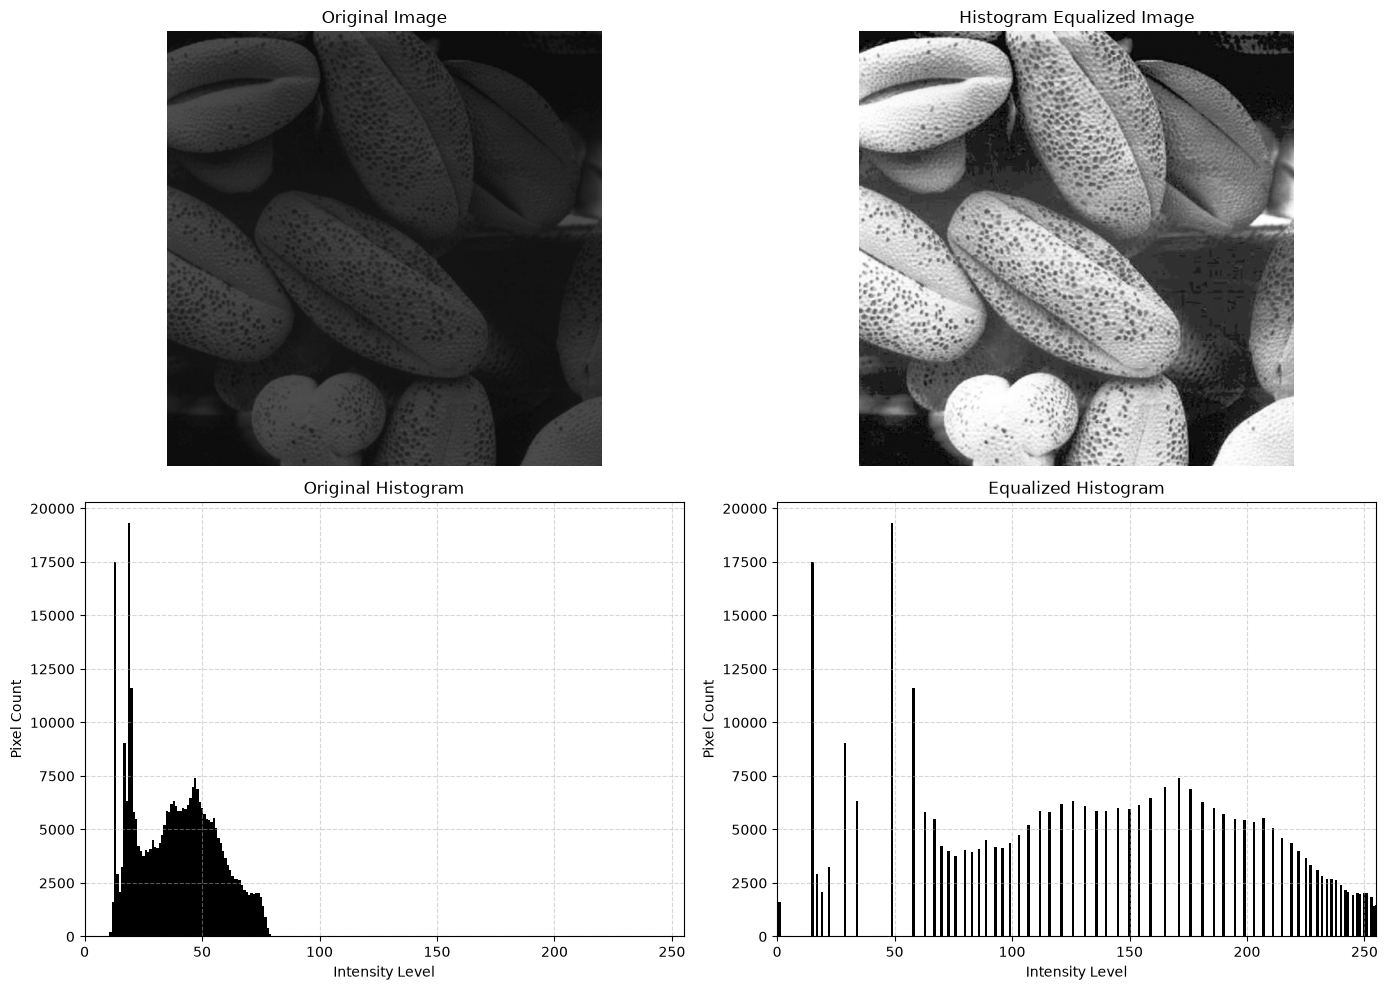

In [ ]:
def custom_histogram_equalization(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    num_pixels = img.size
    
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    
    pdf = hist / num_pixels
    cdf = np.cumsum(pdf)
    transform_map = np.round(255 * cdf).astype(np.uint8)
    
    equalized_img = cv2.LUT(img, transform_map)
    eq_hist, _ = np.histogram(equalized_img.flatten(), bins=256, range=[0, 256])
    
    return equalized_img, hist, eq_hist, transform_map

img_gray = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/histogramPic2.jpg', cv2.IMREAD_GRAYSCALE)  

eq_img, orig_hist, eq_hist, lut_map = custom_histogram_equalization(img_gray)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original Image
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Equalized Image
axes[0, 1].imshow(eq_img, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis("off")

# Original Histogram
axes[1, 0].bar(range(256), orig_hist, color='black', width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity Level")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Equalized Histogram
axes[1, 1].bar(range(256), eq_hist, color='black', width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity Level")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Question 6: Foreground-Only Histogram Equalization

Split into HSV, threshold an appropriate plane to build a foreground mask, histogram-equalize only the foreground using cumulative sums, then recombine with the untouched background.

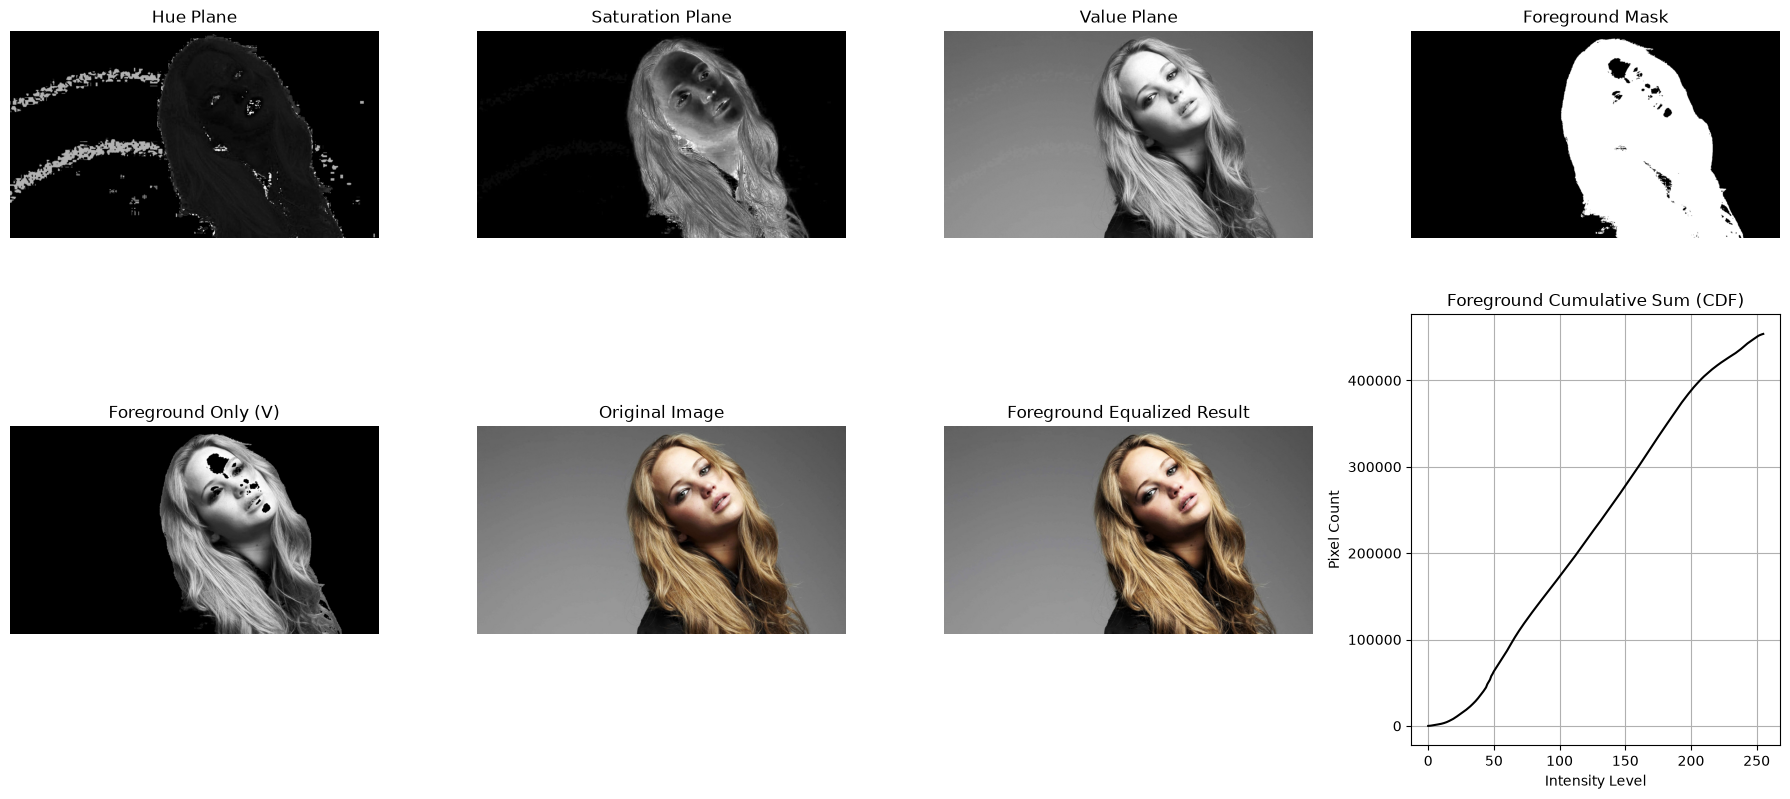

Raw Foreground CDF Array (Pixel Counts): [     0    105    291    525    758   1023   1316   1578   1839   2164
   2463   2853   3288   3766   4357   5001   5729   6477   7232   8112
   9089  10053  11120  12194  13250  14336  15427  16499  17625  18793
  20049  21308  22633  24026  25529  27020  28617  30349  32172  34057
  36094  38072  40060  42259  44515  48354  50969  53514  57728  60279
  63262  65692  68141  70451  72750  75096  77416  79807  82173  84602
  87047  89611  92322  94962  97567 100159 102678 105098 107528 109819
 112093 114359 116534 118718 120840 122966 125158 127250 129297 131310
 133281 135327 137365 139418 141476 143433 145389 147342 149341 151304
 153179 155179 157168 159193 161104 163132 165102 167055 168999 171000
 173094 175076 176974 179004 180940 182902 184940 186946 188922 190931
 193023 195117 197171 199297 201403 203557 205721 207826 209944 212026
 214170 216309 218426 220544 222665 224734 226792 228819 230885 232911
 234962 237057 239182 241321 243372 

In [ ]:
f = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/q6girl.jpeg')
f_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
f_hsv = cv2.cvtColor(f, cv2.COLOR_BGR2HSV)

# split into Hue, Saturation, Value planes
h, s, v = cv2.split(f_hsv)

# extract foreground mask by thresholding Saturation plane
_, mask = cv2.threshold(s, 30, 255, cv2.THRESH_BINARY)

fg_v = cv2.bitwise_and(v, v, mask=mask)
hist, _ = np.histogram(fg_v[mask > 0], bins=256, range=[0, 256])
cdf = np.cumsum(hist)

# the number of intensity levels
L = 256
MN = np.count_nonzero(mask)

t = np.array([((L - 1) / MN) * cdf[k] for k in range(256)], dtype=np.uint8)

equalized_fg = t[fg_v]
equalized_fg = cv2.bitwise_and(equalized_fg, equalized_fg, mask=mask)

# extract background and add with equalized foreground
mask_inv = cv2.bitwise_not(mask)
bg_v = cv2.bitwise_and(v, v, mask=mask_inv)
v_final = cv2.add(equalized_fg, bg_v)

# recombine the HSV channels and convert back to RGB
hsv_final = cv2.merge([h, s, v_final])
rgb_final = cv2.cvtColor(hsv_final, cv2.COLOR_HSV2RGB)

# Display All Results
fig, ax = plt.subplots(2, 4, figsize=(18, 9))

ax[0, 0].imshow(h, cmap='gray')
ax[0, 0].set_title('Hue Plane')
ax[0, 0].axis('off')

ax[0, 1].imshow(s, cmap='gray')
ax[0, 1].set_title('Saturation Plane')
ax[0, 1].axis('off')

ax[0, 2].imshow(v, cmap='gray')
ax[0, 2].set_title('Value Plane')
ax[0, 2].axis('off')

ax[0, 3].imshow(mask, cmap='gray')
ax[0, 3].set_title('Foreground Mask')
ax[0, 3].axis('off')

ax[1, 0].imshow(fg_v, cmap='gray')
ax[1, 0].set_title('Foreground Only (V)')
ax[1, 0].axis('off')

ax[1, 1].imshow(f_rgb)
ax[1, 1].set_title('Original Image')
ax[1, 1].axis('off')

ax[1, 2].imshow(rgb_final)
ax[1, 2].set_title('Foreground Equalized Result')
ax[1, 2].axis('off')

ax[1, 3].plot(cdf, color='black')
ax[1, 3].set_title('Foreground Cumulative Sum (CDF)')
ax[1, 3].set_xlabel('Intensity Level')
ax[1, 3].set_ylabel('Pixel Count')
ax[1, 3].grid(True)

plt.tight_layout()
plt.show()


print(f"Raw Foreground CDF Array (Pixel Counts): {cdf}")

# Print the normalized CDF (mapped from 0.0 to 1.0)
cdf_normalized = cdf / MN
print(f"\nNormalized CDF Array: {cdf_normalized}")

# Print the final intensity mapping table (0 to 255)
print(f"\nTransformation Mapping Array (LUT): {t}")

## Question 7: Sobel Filtering

(a) Use cv.filter2D with Sobel kernels. (b) Implement Sobel filtering manually. (c) Exploit the separable kernel property to filter with 1D convolutions.

Max pixel difference between cv2.filter2D and custom 2D: 0
Max pixel difference between 2D Sobel and 1D Separated Sobel: 0


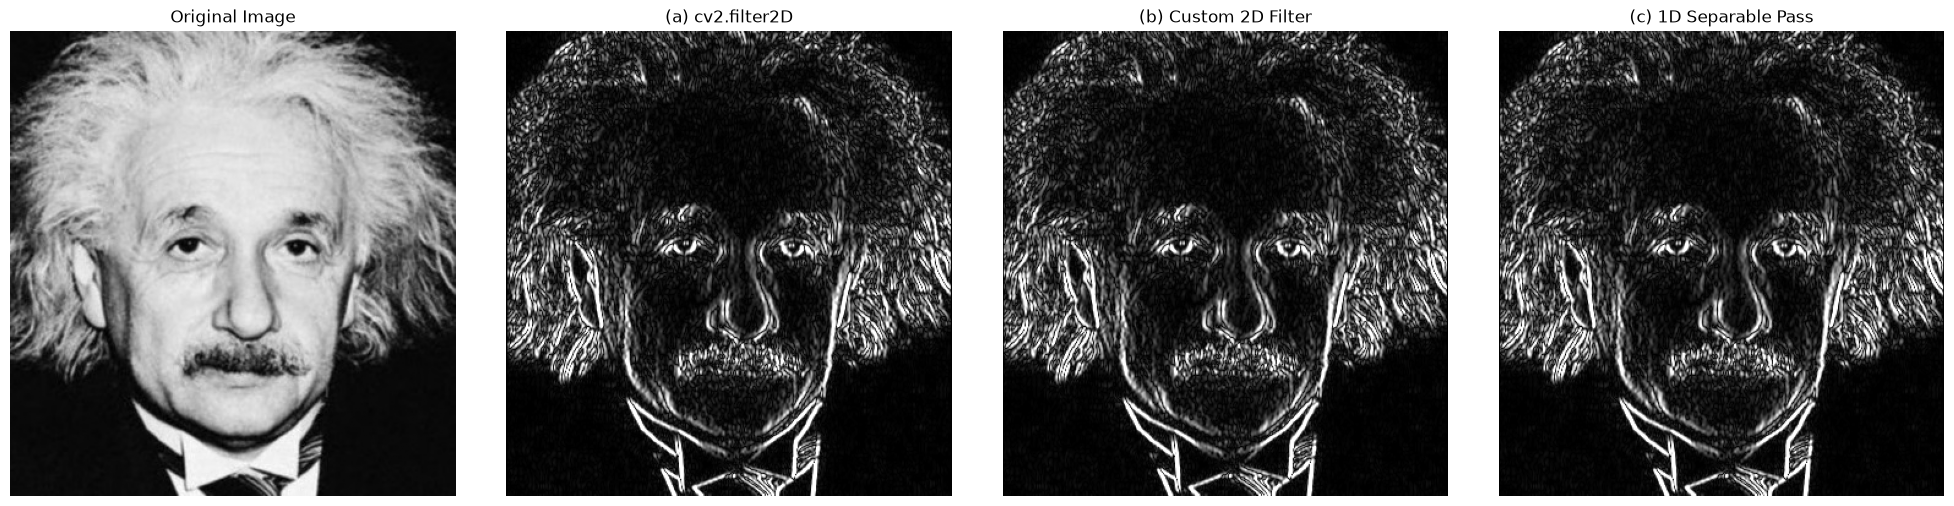

In [ ]:
img_gray = cv2.imread('/home/lasan-perera/University(Aca)/CV Assignment 1/images/q7AlbertEinstien.jpeg', cv2.IMREAD_GRAYSCALE)  

# sobel horizontal kernel   
K_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

# sobel 
sobel_cv2 = cv2.filter2D(img_gray.astype(np.float32), -1, K_x)
sobel_a = cv2.convertScaleAbs(sobel_cv2)

def custom_2d_convolution(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    # Zero-padding
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    
    # Spatial Convolution
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
            
    return np.clip(np.abs(output), 0, 255).astype(np.uint8)

sobel_b = custom_2d_convolution(img_gray, K_x)


v_kernel = np.array([[1], [2], [1]], dtype=np.float32)    # Vertical smoothing
h_kernel = np.array([[1, 0, -1]], dtype=np.float32)      # Horizontal derivative

# vertical 1D Pass
temp_vertical = cv2.filter2D(img_gray.astype(np.float32), -1, v_kernel)

# horizontal 1D Pass
sobel_c_64f = cv2.filter2D(temp_vertical, -1, h_kernel)
sobel_c = cv2.convertScaleAbs(sobel_c_64f)


diff_ab = np.max(np.abs(sobel_a.astype(int) - sobel_b.astype(int)))
diff_ac = np.max(np.abs(sobel_a.astype(int) - sobel_c.astype(int)))

print(f"Max pixel difference between cv2.filter2D and custom 2D: {diff_ab}")
print(f"Max pixel difference between 2D Sobel and 1D Separated Sobel: {diff_ac}")

# Visualization 
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(sobel_a, cmap='gray')
axes[1].set_title("(a) cv2.filter2D")
axes[1].axis("off")

axes[2].imshow(sobel_b, cmap='gray')
axes[2].set_title("(b) Custom 2D Filter")
axes[2].axis("off")

axes[3].imshow(sobel_c, cmap='gray')
axes[3].set_title("(c) 1D Separable Pass")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Question 8: Image Zooming (Nearest-Neighbor and Bilinear)

Write a zoom function supporting nearest-neighbor and bilinear interpolation for scale factor s in (0, 10]. Evaluate using normalized SSD against the original when scaling up by 4x.

## Question 9: GrabCut Segmentation and Background Blur

(a) Segment the flower image with cv.grabCut, showing mask, foreground, and background. (b) Blur the background to produce a bokeh-style enhanced image. (c) Discuss the dark rim artifact.

## Question 10: Bilateral Filtering

(a) Use cv.bilateralFilter and compare against a similarly-sized Gaussian blur. (b) Implement your own bilateral filter, compare against OpenCV's version with a quantitative measure.